In [8]:
# =========================================================
# COMPLETE AUTONOMOUS MULTI-AGENT PIPELINE
# PREPROCESSING → DEBUGGING → MODEL SELECTION
# → HYPERPARAMETER TUNING → FORECASTING
# =========================================================

import os
import io
import sys
import warnings
import logging
import traceback

import pandas as pd
import numpy as np

from math import sqrt

from typing import (
    TypedDict,
    List,
    Dict,
    Optional
)

from dotenv import load_dotenv

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.model_selection import (ParameterGrid)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet
from pmdarima import auto_arima

from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import (StateGraph,END)

from rich.console import Console
from rich.panel import Panel
from rich.syntax import Syntax
from rich.table import Table
from rich import box

In [9]:
# =========================================================
# CONFIGURATION
# =========================================================

load_dotenv(".env")
gemini_api_key = os.getenv("GEMINI_API_KEY")
DATASET_PATH = "dataset.csv"
PREPROCESSED_DATASET = "Final_Dataset.csv"
TARGET_COLUMN = "quantity_sold"
FORECAST_DAYS = 7


# =========================================================
# LOGGING
# =========================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")
console = Console()

In [10]:
# =========================================================
# LOAD DATASET
# =========================================================
df = pd.read_csv(DATASET_PATH)
console.print(
    "\n[bold green]"
    "Dataset Loaded Successfully"
    "[/bold green]\n"
)
# =========================================================
# DISPLAY DATASET
# =========================================================

preview_table = Table(
    title="Dataset Preview",
    box=box.DOUBLE_EDGE
)

for col in df.columns:
    preview_table.add_column(col)
for _, row in df.head().iterrows():
    preview_table.add_row(
        *[str(i) for i in row]
    )
console.print(preview_table)

Dataset Loaded Successfully

                        Dataset Preview                        
╔════════════╤═════════╤══════════╤═══════════════╤═══════════╗
║ date       │ sku     │ location │ quantity_sold │ inventory ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-01 │ SKU_101 │ Chennai  │ 52.0          │ 120       ║
║ 2024-01-02 │ SKU_101 │ Chennai  │ 49.0          │ 115       ║
║ 2024-01-03 │ SKU_101 │ Chennai  │ nan           │ 110       ║
║ 2024-01-04 │ SKU_101 │ Chennai  │ 55.0          │ 105       ║
║ 2024-01-05 │ SKU_101 │ Chennai  │ 60.0          │ 100       ║
╚════════════╧═════════╧══════════╧═══════════════╧═══════════╝

In [11]:
# =========================================================
# LLM
# =========================================================

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY"),
)

# =========================================================
# PREPROCESSING TASKS
# =========================================================

PREPROCESSING_TASKS = [
    "Display dataset summary",
    "Print number of rows, columns and column names",
    "Identify numerical and categorical columns",
    "Handle missing values",
    "Handle outliers using IQR for numeric columns only",
    "Find duplicate rows"
]

In [12]:
# =========================================================
# STATE
# =========================================================

class TradingState(TypedDict):
    # preprocessing
    df: pd.DataFrame
    tasks: List[str]
    task_index: int
    current_task: str
    generated_code: str
    preprocessing_output: str
    preprocessing_error: Optional[str]
    retry_count: int
    max_retries: int
    debug_history: List[str]
    last_error: str
    # forecasting
    models: List[str]
    results: List[Dict]
    best_model: str
    tuning_method: str
    best_params: Dict
    forecast_df: pd.DataFrame

In [13]:
# =========================================================
# PREPROCESSING PLANNER
# =========================================================

def preprocessing_planner(state):
    index = state["task_index"]
    task = state["tasks"][index]
    console.print(
        f"\n[bold cyan]"
        f"PREPROCESSING TASK {index + 1}"
        f"[/bold cyan]"
    )
    console.print(
        f"[yellow]{task}[/yellow]"
    )
    return {
        "current_task": task
    }

# =========================================================
# PREPROCESSING CODER
# =========================================================
def preprocessing_coder(state):
    task = state["current_task"]
    prompt = f"""
You are a senior Python preprocessing engineer.

Rules:
1. Dataframe name is df
2. Use pandas and numpy only
3. Do not reload dataset
4. Return executable Python code only
5. Print meaningful output
6. Update df if preprocessing is applied

Task:
{task}
"""

    response = llm.invoke(prompt)
    code = response.content
    code = code.replace(
        "```python",
        ""
    )
    code = code.replace(
        "```",
        ""
    )
    code = code.strip()

    console.print(

        "\n[bold green]"
        "Generated Code"
        "[/bold green]\n"
    )

    syntax = Syntax(
        code,
        "python",
        theme="monokai"
    )

    console.print(syntax)

    return {
        "generated_code": code
    }

# =========================================================
# PREPROCESSING EXECUTOR
# =========================================================

def preprocessing_executor(state):
    code = state["generated_code"]
    dataframe = state["df"]
    local_vars = {
        "df": dataframe.copy(),
        "pd": pd,
        "np": np
    }
    buffer = io.StringIO()
    try:
        sys.stdout = buffer
        exec(code, {}, local_vars)
        sys.stdout = sys.__stdout__
        updated_df = local_vars.get(
            "df",
            dataframe
        )
        output = buffer.getvalue()
        console.print(
            Panel(
                output if output else "Execution Completed",
                title="Execution Output",
                style="bold green"
            )
        )

        return {
            "df": updated_df,
            "preprocessing_output": output,
            "preprocessing_error": None,
            "last_error": ""
        }

    except Exception:
        sys.stdout = sys.__stdout__
        error_message = traceback.format_exc()
        console.print(
            Panel(
                error_message,
                title="Execution Failed",
                style="bold red"
            )
        )
        return {
            "preprocessing_error": error_message,
            "last_error": error_message
        }


In [14]:
# =========================================================
# DEBUGGER AGENT
# =========================================================

def debugger_agent(state):
    console.print(
        "\n[bold red]"
        "DEBUGGER AGENT ACTIVATED"
        "[/bold red]"
    )
    task = state["current_task"]
    original_code = state["generated_code"]
    error_message = state["last_error"]
    debug_prompt = f"""
You are an expert Python debugging engineer.

Task:
{task}

Original Code:
{original_code}

Execution Error:
{error_message}

Rules:
1. Fix the error
2. Preserve original logic
3. Dataframe name must remain df
4. Use pandas and numpy only
5. Return ONLY executable Python code
6. Do not explain anything
7. Ensure numeric-only operations are handled correctly
"""

    response = llm.invoke(debug_prompt)
    fixed_code = response.content.strip()
    fixed_code = fixed_code.replace(
        "```python",
        ""
    )
    fixed_code = fixed_code.replace(
        "```",
        ""
    )
    console.print(

        "\n[bold yellow]"
        "FIXED CODE GENERATED"
        "[/bold yellow]\n"
    )
    syntax = Syntax(
        fixed_code,
        "python",
        theme="monokai"
    )

    console.print(syntax)
    debug_history = state["debug_history"]
    debug_history.append(error_message)

    return {
        "generated_code": fixed_code,
        "retry_count":
        state["retry_count"] + 1,
        "debug_history": debug_history
    }

In [15]:
# =========================================================
# EXECUTION ROUTER
# =========================================================

def execution_router(state):
    if state["preprocessing_error"] is None:
        return "preprocessing_checker"
    if state["retry_count"] >= state["max_retries"]:
        return END
    return "debugger_agent"

# =========================================================
# PREPROCESSING CHECKER
# =========================================================
def preprocessing_checker(state):
    console.print(
        "\n[bold green]"
        "Preprocessing Completed"
        "[/bold green]"
    )
    return {}

# =========================================================
# NEXT TASK
# =========================================================

def next_task_agent(state):
    return {
        "task_index":
        state["task_index"] + 1,
        "retry_count": 0
    }

# =========================================================
# PREPROCESSING ROUTER
# =========================================================

def preprocessing_router(state):
    next_index = state["task_index"] + 1
    if next_index >= len(state["tasks"]):
        return "forecast_planner"
    return "preprocessing_planner"

In [ ]:

# =========================================================
# FORECAST PLANNER
# =========================================================

def forecast_planner(state):
    console.print(

        "\n[bold magenta]"
        "MODEL SELECTION PHASE"
        "[/bold magenta]"
    )

    models = [
        "ARIMA",
        "SARIMAX",
        "Prophet"
    ]

    if len(state["df"]) > 500:

        models.append("LSTM")

    console.print(

        f"Models Selected → {models}"
    )

    return {

        "models": models
    }


# =========================================================
# PREPARE FORECAST DATA
# =========================================================

def prepare_forecasting_data(df):

    df["date"] = pd.to_datetime(
        df["date"]
    )

    df = df.sort_values("date")

    df.set_index(
        "date",
        inplace=True
    )

    df = df.asfreq("D")

    df["lag1"] = df[
        TARGET_COLUMN
    ].shift(1)

    df["lag7"] = df[
        TARGET_COLUMN
    ].shift(7)

    df = df.dropna()

    split_index = int(
        len(df) * 0.8
    )

    train = df.iloc[:split_index]
    test = df.iloc[split_index:]
    y_train = train[TARGET_COLUMN]
    y_test = test[TARGET_COLUMN]
    return df, y_train, y_test


# =========================================================
# METRICS
# =========================================================

def evaluate(actual, pred):

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = sqrt(

        mean_squared_error(
            actual,
            pred
        )
    )

    mape = np.mean(

        np.abs(
            (actual - pred)
            / (actual + 1e-10)
        )
    ) * 100

    return {

        "MAE": round(mae, 3),

        "RMSE": round(rmse, 3),

        "MAPE": round(mape, 3)
    }


# =========================================================
# FORECAST EXECUTOR
# =========================================================

def forecast_executor(state):

    console.print(

        "\n[bold yellow]"
        "Running Forecast Models"
        "[/bold yellow]"
    )

    results = []

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    for model_name in state["models"]:

        try:

            if model_name == "ARIMA":

                model = ARIMA(
                    y_train,
                    order=(1,1,1)
                )

                fit = model.fit()

                pred = fit.forecast(
                    len(y_test)
                )


            elif model_name == "SARIMAX":

                model = SARIMAX(
                    y_train,
                    order=(1,1,1)
                )

                fit = model.fit()

                pred = fit.forecast(
                    len(y_test)
                )


            elif model_name == "Prophet":

                prophet_df = (
                    processed_df
                    .reset_index()[[
                        "date",
                        TARGET_COLUMN
                    ]]
                )

                prophet_df.columns = [
                    "ds",
                    "y"
                ]

                split = int(
                    len(prophet_df) * 0.8
                )

                train_p = prophet_df.iloc[:split]
                test_p = prophet_df.iloc[split:]

                model = Prophet()

                model.fit(train_p)

                future = model.make_future_dataframe(
                    periods=len(test_p)
                )

                forecast = model.predict(
                    future
                )

                pred = forecast[
                    "yhat"
                ].iloc[-len(test_p):]

                metrics = evaluate(
                    test_p["y"],
                    pred
                )

                results.append({

                    "Model": model_name,

                    **metrics
                })

                continue

            metrics = evaluate(
                y_test,
                pred
            )

            results.append({

                "Model": model_name,

                **metrics
            })

            console.print(

                f"[green]"
                f"{model_name} Completed"
                f"[/green]"
            )

        except Exception as e:

            logger.exception(e)

    return {

        "results": results
    }


# =========================================================
# MODEL CHECKER
# =========================================================

def model_checker(state):

    results_df = pd.DataFrame(
        state["results"]
    )

    table = Table(
        title="Model Results",
        box=box.DOUBLE_EDGE
    )

    for col in results_df.columns:
        table.add_column(col)

    for _, row in results_df.iterrows():
        table.add_row(
            *[str(i) for i in row]
        )

    console.print(table)

    return {}


# =========================================================
# BEST MODEL SELECTOR
# =========================================================

def best_model_selector(state):

    results_df = pd.DataFrame(
        state["results"]
    )

    best_row = results_df.sort_values(
        "RMSE"
    ).iloc[0]

    best_model = best_row["Model"]

    console.print(

        f"\n[bold green]"
        f"Best Model → {best_model}"
        f"[/bold green]"
    )

    return {

        "best_model": best_model
    }


# =========================================================
# TUNING AGENT
# =========================================================

def tuning_agent(state):

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    param_grid = {

        "p": [0,1,2],

        "d": [0,1],

        "q": [0,1,2]
    }

    best_score = np.inf
    best_params = None

    for params in ParameterGrid(param_grid):

        try:

            model = ARIMA(

                y_train,

                order=(
                    params["p"],
                    params["d"],
                    params["q"]
                )
            ).fit()

            pred = model.forecast(
                len(y_test)
            )

            rmse = evaluate(
                y_test,
                pred
            )["RMSE"]

            if rmse < best_score:

                best_score = rmse

                best_params = params

        except:
            pass

    auto_model = auto_arima(

        y_train,

        seasonal=False
    )

    auto_pred = auto_model.predict(
        n_periods=len(y_test)
    )

    auto_rmse = evaluate(
        y_test,
        auto_pred
    )["RMSE"]

    scores = {

        "GridSearch": best_score,

        "AutoARIMA": auto_rmse
    }

    best_method = min(
        scores,
        key=scores.get
    )

    console.print(

        f"\nBest Tuning Method → "
        f"{best_method}"
    )

    return {

        "tuning_method": best_method,

        "best_params": best_params
    }


# =========================================================
# FORECASTING AGENT
# =========================================================

def forecasting_agent(state):

    processed_df, y_train, y_test = (
        prepare_forecasting_data(
            state["df"].copy()
        )
    )

    y_full = processed_df[
        TARGET_COLUMN
    ]

    best_model = state["best_model"]

    if best_model == "ARIMA":

        model = ARIMA(
            y_full,
            order=(1,1,1)
        )

        fit = model.fit()

        forecast = fit.forecast(
            steps=FORECAST_DAYS
        )


    elif best_model == "SARIMAX":

        model = SARIMAX(
            y_full,
            order=(1,1,1)
        )

        fit = model.fit()

        forecast = fit.forecast(
            steps=FORECAST_DAYS
        )


    elif best_model == "Prophet":

        prophet_df = (
            processed_df
            .reset_index()[[
                "date",
                TARGET_COLUMN
            ]]
        )

        prophet_df.columns = [
            "ds",
            "y"
        ]

        model = Prophet()

        model.fit(prophet_df)

        future = model.make_future_dataframe(
            periods=FORECAST_DAYS
        )

        forecast_result = model.predict(
            future
        )

        forecast = forecast_result[
            "yhat"
        ].tail(
            FORECAST_DAYS
        ).values


    future_dates = pd.date_range(

        start=processed_df.index[-1]
        + pd.Timedelta(days=1),

        periods=FORECAST_DAYS
    )

    forecast_df = pd.DataFrame({

        "Date": future_dates,

        "Forecast": forecast
    })

    console.print(

        Panel(

            str(forecast_df),

            title="Forecast Output"
        )
    )

    return {

        "forecast_df": forecast_df
    }



In [17]:
# =========================================================
# BUILD GRAPH
# =========================================================

builder = StateGraph(TradingState)


# =========================================================
# PREPROCESSING NODES
# =========================================================

builder.add_node(
    "preprocessing_planner",
    preprocessing_planner
)

builder.add_node(
    "preprocessing_coder",
    preprocessing_coder
)

builder.add_node(
    "preprocessing_executor",
    preprocessing_executor
)

builder.add_node(
    "debugger_agent",
    debugger_agent
)

builder.add_node(
    "preprocessing_checker",
    preprocessing_checker
)

builder.add_node(
    "next_task",
    next_task_agent
)


# =========================================================
# FORECASTING NODES
# =========================================================

builder.add_node(
    "forecast_planner",
    forecast_planner
)

builder.add_node(
    "forecast_executor",
    forecast_executor
)

builder.add_node(
    "model_checker",
    model_checker
)

builder.add_node(
    "best_model_selector",
    best_model_selector
)

builder.add_node(
    "tuning_agent",
    tuning_agent
)

builder.add_node(
    "forecasting_agent",
    forecasting_agent
)


# =========================================================
# ENTRY POINT
# =========================================================

builder.set_entry_point(
    "preprocessing_planner"
)


# =========================================================
# PREPROCESSING FLOW
# =========================================================

builder.add_edge(
    "preprocessing_planner",
    "preprocessing_coder"
)

builder.add_edge(
    "preprocessing_coder",
    "preprocessing_executor"
)


# =========================================================
# EXECUTION ROUTING
# =========================================================

builder.add_conditional_edges(

    "preprocessing_executor",

    execution_router,

    {

        "preprocessing_checker":
        "preprocessing_checker",

        "debugger_agent":
        "debugger_agent",

        END: END
    }
)


# =========================================================
# DEBUG LOOP
# =========================================================

builder.add_edge(
    "debugger_agent",
    "preprocessing_executor"
)


# =========================================================
# CONTINUE PREPROCESSING
# =========================================================

builder.add_edge(
    "preprocessing_checker",
    "next_task"
)

builder.add_conditional_edges(

    "next_task",

    preprocessing_router,

    {

        "preprocessing_planner":
        "preprocessing_planner",

        "forecast_planner":
        "forecast_planner"
    }
)



In [18]:
# =========================================================
# FORECAST FLOW
# =========================================================

builder.add_edge(
    "forecast_planner",
    "forecast_executor"
)

builder.add_edge(
    "forecast_executor",
    "model_checker"
)

builder.add_edge(
    "model_checker",
    "best_model_selector"
)

builder.add_edge(
    "best_model_selector",
    "tuning_agent"
)

builder.add_edge(
    "tuning_agent",
    "forecasting_agent"
)

builder.add_edge(
    "forecasting_agent",
    END
)


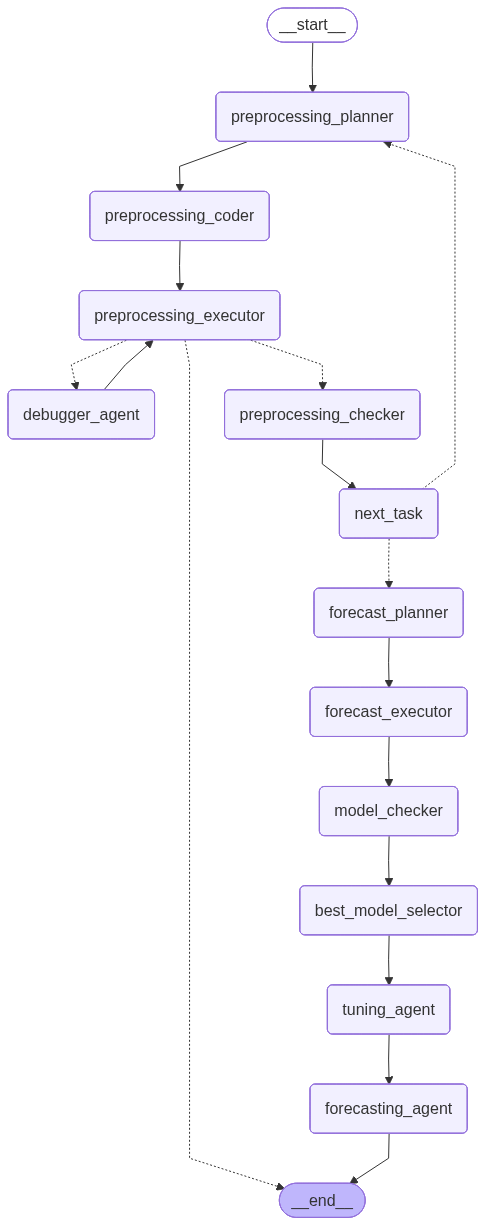

In [19]:
# =========================================================
# COMPILE GRAPH
# =========================================================

graph = builder.compile()


# =========================================================
# VISUALIZE GRAPH
# =========================================================

from IPython.display import (
    Image,
    display
)

graph_png = graph.get_graph().draw_mermaid_png()

display(Image(graph_png))

#print(
 #   graph.get_graph().draw_ascii()
#)


Graph image saved successfully!


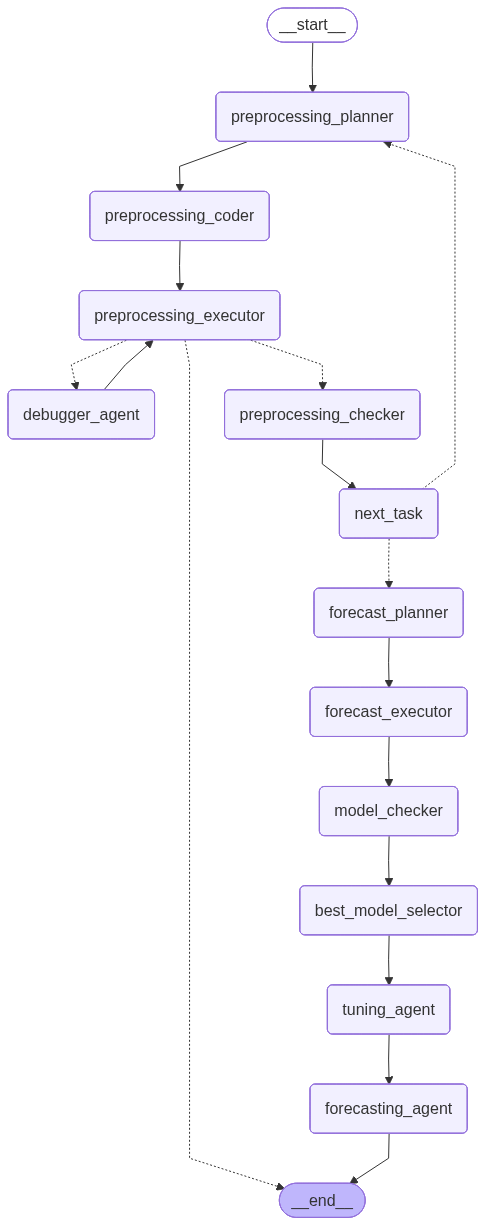

In [20]:
# Save image
with open("langgraph.png", "wb") as f:
    f.write(graph_png)

print("Graph image saved successfully!")

# Display image
display(Image(graph_png))

In [ ]:


# =========================================================
# RUN GRAPH
# =========================================================

final_state = graph.invoke({

    "df": df,
    "tasks": PREPROCESSING_TASKS,
    "task_index": 0,
    "current_task": "",
    "generated_code": "",
    "preprocessing_output": "",
    "preprocessing_error": None,
    "retry_count": 0,
    "max_retries": 3,
    "debug_history": [],
    "last_error": "",
    "models": [],
    "results": [],
    "best_model": "",
    "tuning_method": "",
    "best_params": {},
    "forecast_df": None
},
config={
    "recursion_limit": 100
})


# =========================================================
# SAVE PREPROCESSED DATA
# =========================================================

final_state["df"].to_csv(
    PREPROCESSED_DATASET,
    index=False
)

# =========================================================
# SAVE FORECAST
# =========================================================

final_state["forecast_df"].to_csv(
    "Forecast_Output.csv",
    index=False
)


# =========================================================
# COMPLETION
# =========================================================

console.print(

    "\n[bold green]"
    "AUTONOMOUS MULTI-AGENT PIPELINE COMPLETED"
    "[/bold green]"
)

PREPROCESSING TASK 1

Display dataset summary

Generated Code

print("--- Dataset Info ---")                                                                                      
print(df.info())                                                                                                   
                                                                                                                   
print("\n--- Missing Values ---")                                                                                  
print(df.isnull().sum())                                                                                           
                                                                                                                   
print("\n--- Descriptive Statistics ---")                                                                          
print(df.describe(include='all'))                                                                                  
                                                                                                                   
print("\n--- First 5 Rows ---")                                                                                    
print(df.head())                                                                                                   

╭─────────────────────────────────────────────── Execution Output ────────────────────────────────────────────────╮
│ --- Dataset Info ---                                                                                            │
│ <class 'pandas.DataFrame'>                                                                                      │
│ RangeIndex: 30 entries, 0 to 29                                                                                 │
│ Data columns (total 5 columns):                                                                                 │
│  #   Column         Non-Null Count  Dtype                                                                       │
│ ---  ------         --------------  -----                                                                       │
│  0   date           30 non-null     str                                                                         │
│  1   sku            30 non-null     str                                                                         │
│  2   location       30 non-null     str                                                                         │
│  3   quantity_sold  28 non-null     float64                                                                     │
│  4   inventory      30 non-null     int64                                                                       │
│ dtypes: float64(1), int64(1), str(3)                                                                            │
│ memory usage: 1.3 KB                                                                                            │
│ None                                                                                                            │
│                                                                                                                 │
│ --- Missing Values ---                                                                                          │
│ date             0                                                                                              │
│ sku              0                                                                                              │
│ location         0                                                                                              │
│ quantity_sold    2                                                                                              │
│ inventory        0                                                                                              │
│ dtype: int64                                                                                                    │
│                                                                                                                 │
│ --- Descriptive Statistics ---                                                                                  │
│               date      sku location  quantity_sold   inventory                                                 │
│ count           30       30       30      28.000000   30.000000                                                 │
│ unique          30        1        1            NaN         NaN                                                 │
│ top     2024-01-01  SKU_101  Chennai            NaN         NaN                                                 │
│ freq             1       30       30            NaN         NaN                                                 │
│ mean           NaN      NaN      NaN      81.964286   51.500000                                                 │
│ std            NaN      NaN      NaN      95.572537   38.799884                                                 │
│ min            NaN      NaN      NaN      -5.000000    0.000000                                                 │
│ 25%            NaN      NaN      NaN      55.750000   16.250000                                                 │
│ 50%            NaN      NaN      NaN      62.500000   

...

           Model Results           
╔═════════╤═══════╤═══════╤═══════╗
║ Model   │ MAE   │ RMSE  │ MAPE  ║
╟─────────┼───────┼───────┼───────╢
║ ARIMA   │ 2.883 │ 3.475 │ 3.983 ║
║ SARIMAX │ 2.883 │ 3.475 │ 3.983 ║
║ Prophet │ 2.37  │ 4.08  │ 3.356 ║
╚═════════╧═══════╧═══════╧═══════╝

Best Model → ARIMA

Best Tuning Method → GridSearch

╭──────────────────────────────────────────────── Forecast Output ────────────────────────────────────────────────╮
│                  Date   Forecast                                                                                │
│ 2024-01-31 2024-01-31  71.469323                                                                                │
│ 2024-02-01 2024-02-01  71.069293                                                                                │
│ 2024-02-02 2024-02-02  71.006060                                                                                │
│ 2024-02-03 2024-02-03  70.996065                                                                                │
│ 2024-02-04 2024-02-04  70.994485                                                                                │
│ 2024-02-05 2024-02-05  70.994235                                                                                │
│ 2024-02-06 2024-02-06  70.994195                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

AUTONOMOUS MULTI-AGENT PIPELINE COMPLETED